In [47]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    auc,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)

from birdclef_2026_ml.configs import artifact_stem, load_experiment_config
from birdclef_2026_ml.inference.ovr_inference import run_ovr_inference
from birdclef_2026_ml.notebooks.notebook_utils import init_notebook
from birdclef_2026_ml.paths import load_project_paths
from birdclef_2026_ml.processing.memmap_dataset import load_memmap_dataset

paths = load_project_paths()
sns.set_theme(style="whitegrid")
init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Clean-Audio ROC/AP Curves

In [70]:
run_name = "run_chunks_overlap"
experiment_name = "sgd_baseline"
reduced = True

experiment_cfg, _ = load_experiment_config(run_name, experiment_name)
experiment_dir = paths.experiment_dir(run_name, experiment_name)
artifact_path = experiment_dir / f"{artifact_stem(experiment_cfg)}_ovr.joblib"
artifacts = joblib.load(artifact_path)

dataset = load_memmap_dataset(run_name, reduced=reduced, soundscape=False)
val_idx_path = experiment_dir / "val_indices.npy"
if val_idx_path.exists():
    val_idx = np.asarray(np.load(val_idx_path), dtype=int)
else:
    val_idx = np.arange(dataset.X.shape[0], dtype=int)

X_eval = dataset.X[val_idx]
y_eval = np.asarray(dataset.y[val_idx])

#probas, preds = run_ovr_inference(X_eval, artifacts)
probas = np.load("/Volumes/HDD1TB/BirdCLEF2026/artifacts/models/runs/run_chunks_overlap/experiments/sgd_baseline/sgdclassifier_val_probas.npy", allow_pickle=True).item()
class_proba = probas["class_name"]
primary_proba = probas["primary_label"]
class_true = y_eval[:, 0]
primary_true = y_eval[:, 1]

class_names = artifacts.class_name.label_encoder.classes_
primary_names = artifacts.primary_label.label_encoder.classes_
primary_to_class = np.asarray(np.load(paths.primary_to_class / "primary_to_class.npy"), dtype=int)

support = np.bincount(class_true, minlength=len(class_names))
ranked = np.argsort(-support)
class_ids = [int(cid) for cid in ranked if support[cid] > 1]
class_ids = class_ids[:5] if len(class_ids) > 5 else class_ids
if not class_ids:
    raise ValueError("No class names with at least 2 samples in validation set.")
class_labels = [str(class_names[cid]) for cid in class_ids]

def _primary_metrics_for_class(class_id: int) -> pd.DataFrame:
    primary_ids = np.where(primary_to_class == class_id)[0]
    rows = []
    for pid in primary_ids:
        y_bin = (primary_true == pid).astype(int)
        if np.unique(y_bin).size < 2:
            continue
        fpr, tpr, _ = roc_curve(y_bin, primary_proba[:, pid])
        roc_auc = auc(fpr, tpr)
        ap = average_precision_score(y_bin, primary_proba[:, pid])
        rows.append(
            {
                "primary_id": int(pid),
                "primary_name": str(primary_names[pid]),
                "roc_auc": float(roc_auc),
                "ap": float(ap),
            }
        )
    return pd.DataFrame(rows)

primary_metrics = {cid: _primary_metrics_for_class(cid) for cid in class_ids}

[0.60148165 0.34536971 0.49914355 ... 0.93609575 0.92644285 0.90169255]
[0.10678595 0.37478956 0.26521103 ... 0.05572557 0.07992116 0.13172579]
[0.39086644 0.4315716  0.39796827 ... 0.03468297 0.02890078 0.04439518]
[0.02277265 0.02015059 0.01589184 ... 0.00456293 0.00491138 0.00424973]


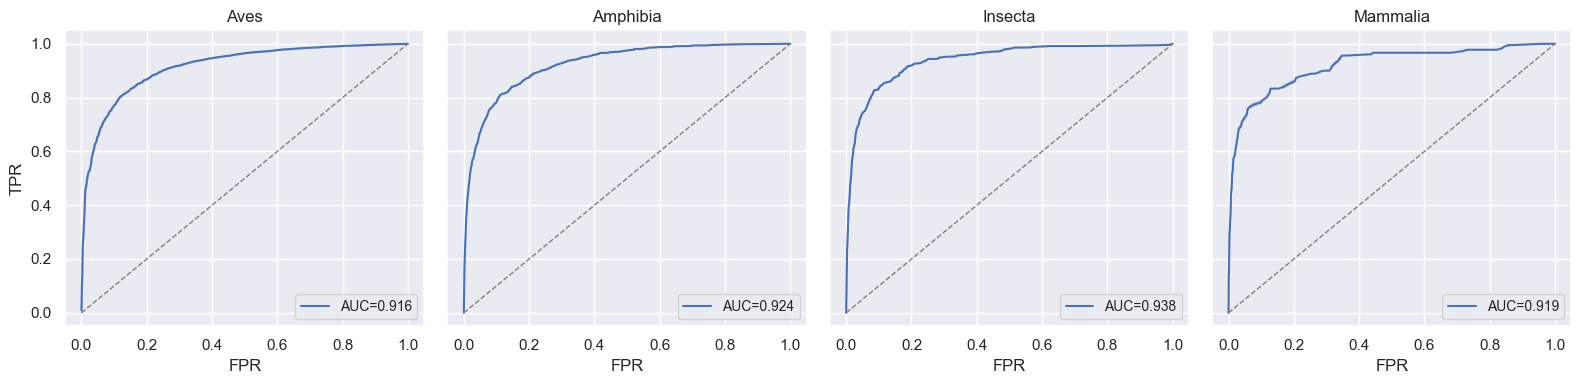

In [ ]:
fig, axes = plt.subplots(1, len(class_ids), figsize=(4 * len(class_ids), 4), sharey=True)
if len(class_ids) == 1:
    axes = [axes]

for ax, class_id in zip(axes, class_ids):
    y_bin = (class_true == class_id).astype(int)
    if np.unique(y_bin).size < 2:
        ax.set_title(f"{class_names[class_id]} (skip)")
        ax.axis("off")
        continue
    fpr, tpr, _ = roc_curve(y_bin, class_proba[:, class_id])
    roc_auc = auc(fpr, tpr)
    sns.lineplot(x=fpr, y=tpr, ax=ax, label=f"AUC={roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    ax.set_title(str(class_names[class_id]))
    ax.set_xlabel("FPR")
    if ax is axes[0]:

        ax.set_ylabel("TPR")
    ax.legend(loc="lower right", fontsize="small")
plt.tight_layout()

[0.60148165 0.34536971 0.49914355 ... 0.93609575 0.92644285 0.90169255]
[0.10678595 0.37478956 0.26521103 ... 0.05572557 0.07992116 0.13172579]
[0.39086644 0.4315716  0.39796827 ... 0.03468297 0.02890078 0.04439518]
[0.02277265 0.02015059 0.01589184 ... 0.00456293 0.00491138 0.00424973]


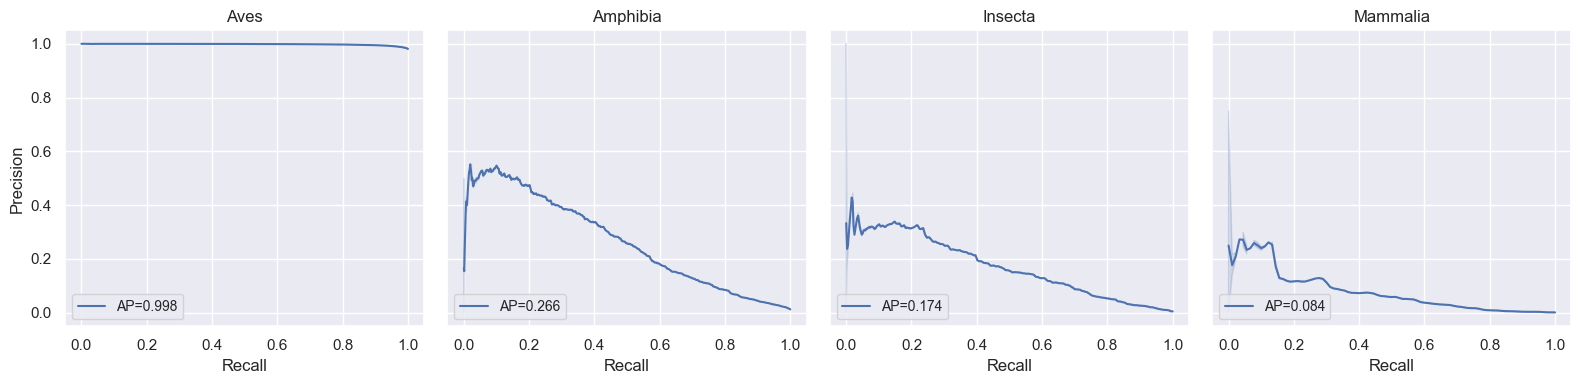

In [ ]:
fig, axes = plt.subplots(1, len(class_ids), figsize=(4 * len(class_ids), 4), sharey=True)
if len(class_ids) == 1:
    axes = [axes]

for ax, class_id in zip(axes, class_ids):
    y_bin = (class_true == class_id).astype(int)
    if np.unique(y_bin).size < 2:
        ax.set_title(f"{class_names[class_id]} (skip)")
        ax.axis("off")
        continue
    precision, recall, _ = precision_recall_curve(y_bin, class_proba[:, class_id])
    ap = average_precision_score(y_bin, class_proba[:, class_id])
    sns.lineplot(x=recall, y=precision, ax=ax, label=f"AP={ap:.3f}")
    ax.set_title(str(class_names[class_id]))
    ax.set_xlabel("Recall")
    if ax is axes[0]:
        ax.set_ylabel("Precision")
    ax.legend(loc="lower left", fontsize="small")
plt.tight_layout()

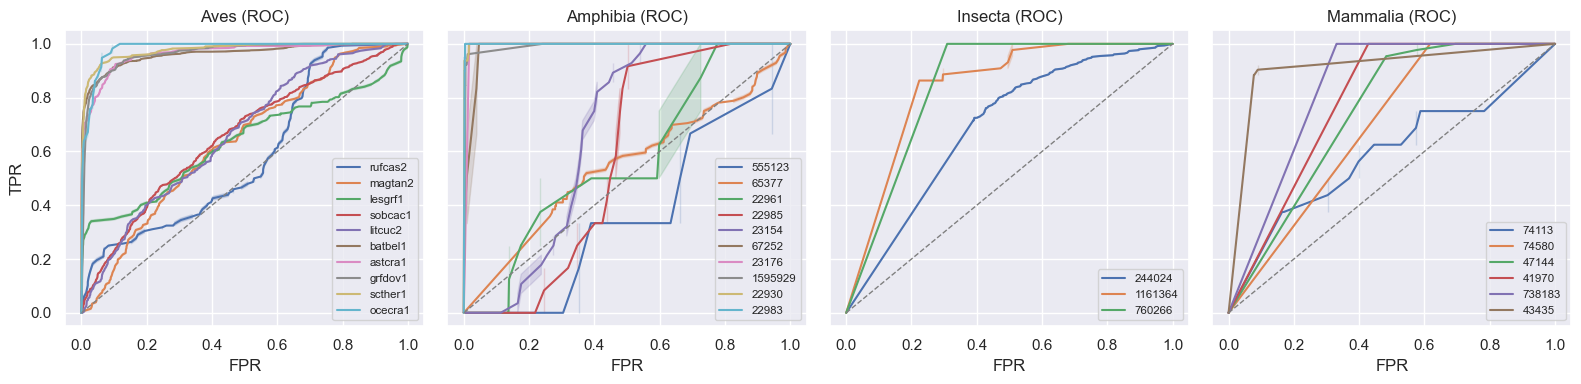

In [52]:
fig, axes = plt.subplots(1, len(class_ids), figsize=(4 * len(class_ids), 4), sharey=True)
if len(class_ids) == 1:
    axes = [axes]

for ax, class_id in zip(axes, class_ids):
    df = primary_metrics.get(class_id, pd.DataFrame())
    if df.empty:
        ax.set_title(f"{class_names[class_id]} (no labels)")
        ax.axis("off")
        continue
    df_sorted = df.sort_values("roc_auc")
    selected = pd.concat([df_sorted.head(5), df_sorted.tail(5)], axis=0)
    selected = selected.drop_duplicates("primary_id")
    for _, row in selected.iterrows():
        pid = int(row["primary_id"])
        y_bin = (primary_true == pid).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, primary_proba[:, pid])
        sns.lineplot(x=fpr, y=tpr, ax=ax, label=row["primary_name"])
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    ax.set_title(f"{class_names[class_id]} (ROC)")
    ax.set_xlabel("FPR")
    if ax is axes[0]:
        ax.set_ylabel("TPR")
    ax.legend(fontsize="x-small", loc="lower right")
plt.tight_layout()

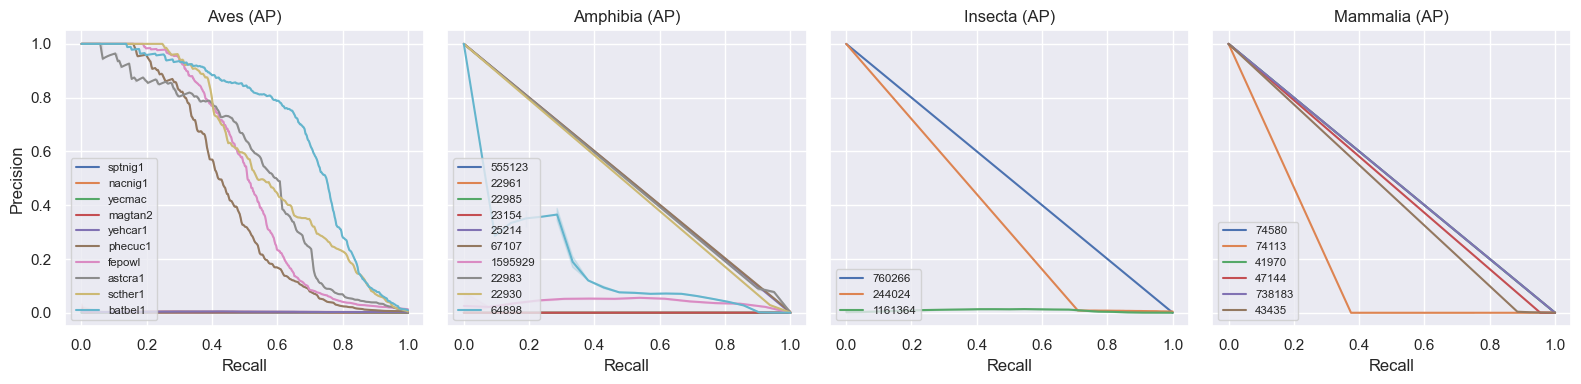

In [63]:
fig, axes = plt.subplots(1, len(class_ids), figsize=(4 * len(class_ids), 4), sharey=True)
if len(class_ids) == 1:
    axes = [axes]

for ax, class_id in zip(axes, class_ids):
    df = primary_metrics.get(class_id, pd.DataFrame())
    if df.empty:
        ax.set_title(f"{class_names[class_id]} (no labels)")
        ax.axis("off")
        continue
    df_sorted = df.sort_values("ap")
    selected = pd.concat([df_sorted.head(5), df_sorted.tail(5)], axis=0)
    selected = selected.drop_duplicates("primary_id")
    for _, row in selected.iterrows():
        pid = int(row["primary_id"])
        y_bin = (primary_true == pid).astype(int)
        precision, recall, _ = precision_recall_curve(y_bin, primary_proba[:, pid])
        sns.lineplot(x=recall, y=precision, ax=ax, label=row["primary_name"])
    ax.set_title(f"{class_names[class_id]} (AP)")
    ax.set_xlabel("Recall")
    if ax is axes[0]:
        ax.set_ylabel("Precision")
    ax.legend(fontsize="x-small", loc="lower left")
plt.tight_layout()